# Module 1 — Exploratory Data Analysis for Finance


We will:

1. Load a CSV of daily BSE data and clean it.
2. Compute daily returns and weekly returns.
3. Summarise returns with descriptive statistics.
4. Visualise prices, returns, and volatility.
5. Compare distribution shape at daily vs weekly horizons.
6. Detect outliers using IQR and z-score rules.
7. Standardise returns so the two stocks can be compared directly.

Each step is broken out into its own cell so you can see exactly what pandas is doing. Once you understand the steps you can wrap them into functions yourself (that's one of the exercises at the end).


## 0. Imports

We'll use four libraries:

- **pandas** — tabular data
- **numpy** — numerical array operations
- **matplotlib** / **seaborn** — plots
- **scipy.stats** — statistical distributions (we use it for the normal in Q-Q plots and density overlays)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.precision', 4)


## 1. Load the SBI CSV, step by step

We will now load `sbi.csv` one operation at a time and inspect the result after each operation.


### 1.1  Read the raw CSV

`pd.read_csv` returns a DataFrame. We'll store it in a variable called `sbi`.


In [4]:
sbi = pd.read_csv('datasets/sbi.csv')
sbi.head()

,Date,Open Price,High Price,Low Price,Close Price,WAP,No.of Shares,No. of Trades,Total Turnover (Rs.),Deliverable Quantity,% Deli. Qty to Traded Qty,Spread High-Low,Spread Close-Open
0,21-April-2026,1114.00,1115.00,1105.95,1112.15,1111.1657,449659,12002,4.9965e+08,261040,58.05,9.05,-1.85
1,20-April-2026,1077.10,1120.90,1075.55,1107.60,1107.1065,1385938,33952,1.5344e+09,678599,48.96,45.35,30.50
2,17-April-2026,1067.50,1082.00,1061.35,1080.35,1072.7671,709240,17299,7.6085e+08,421408,59.42,20.65,12.85
3,16-April-2026,1079.95,1084.00,1061.60,1067.50,1070.7915,2295163,51351,2.4576e+09,397704,17.33,22.40,-12.45
4,15-April-2026,1079.50,1087.75,1068.10,1071.35,1074.8884,894651,30820,9.6165e+08,409735,45.80,19.65,-8.15


Things to notice in the output:

- The **first row is the most recent date** (21-April-2026) — the file is sorted newest-to-oldest. We'll fix this shortly.
- The `Date` column looks like a string (e.g. `"21-April-2026"`), not a proper date.
- Some columns (e.g. `Deliverable Quantity`) have empty cells on the latest row — that's normal for T-day data that hasn't settled yet.


### 1.2  Confirm column data types

Run `.dtypes` — we want to see whether `Date` is a string (`object`) or a datetime.


In [5]:
sbi.dtypes


Date                          object
Open Price                   float64
High Price                   float64
Low Price                    float64
Close Price                  float64
WAP                          float64
No.of Shares                   int64
No. of Trades                  int64
Total Turnover (Rs.)         float64
Deliverable Quantity           int64
% Deli. Qty to Traded Qty    float64
Spread High-Low              float64
Spread Close-Open            float64
dtype: object

Yes — `Date` is `object` (a string). We need to convert it so that time-series operations (sorting, resampling, slicing) work correctly.


### 1.3  Parse the Date column into a datetime

BSE's date format is day, full month name, year — e.g. `21-April-2026`. The format string for that is `'%d-%B-%Y'`:

- `%d` → day of month as zero-padded number
- `%B` → full month name
- `%Y` → 4-digit year


In [6]:
sbi['Date'] = pd.to_datetime(sbi['Date'], format='%d-%B-%Y')
sbi['Date'].head()


0   2026-04-21
1   2026-04-20
2   2026-04-17
3   2026-04-16
4   2026-04-15
Name: Date, dtype: datetime64[ns]

`dtype: datetime64[ns]` confirms the conversion worked.


### 1.4  Sort by date in chronological order

Currently the earliest date is at the bottom of the DataFrame. Time-series methods like `pct_change()` and `resample()` assume the oldest row comes first, so we sort ascending.


In [ ]:
sbi = sbi.sort_values('Date')
sbi.head()

,Date,Open Price,High Price,Low Price,Close Price,WAP,No.of Shares,No. of Trades,Total Turnover (Rs.),Deliverable Quantity,% Deli. Qty to Traded Qty,Spread High-Low,Spread Close-Open
241,2025-04-30,812.85,812.85,784.45,788.15,792.8184,412886,13571,3.2734e+08,157049,38.04,28.40,-24.70
240,2025-05-02,792.05,802.95,789.25,800.05,795.9029,335006,8100,2.6663e+08,97358,29.06,13.70,8.00
239,2025-05-05,784.95,799.10,783.65,790.00,789.7475,771587,22047,6.0936e+08,292169,37.87,15.45,5.05
238,2025-05-06,792.20,799.00,771.15,774.15,778.2487,761282,23690,5.9247e+08,309770,40.69,27.85,-18.05
237,2025-05-07,762.25,782.55,762.25,776.15,775.8552,581175,14757,4.5091e+08,235513,40.52,20.30,13.90


In [ ]:
sbi.tail()

,Date,Open Price,High Price,Low Price,Close Price,WAP,No.of Shares,No. of Trades,Total Turnover (Rs.),Deliverable Quantity,% Deli. Qty to Traded Qty,Spread High-Low,Spread Close-Open
4,2026-04-15,1079.50,1087.75,1068.10,1071.35,1074.8884,894651,30820,9.6165e+08,409735,45.80,19.65,-8.15
3,2026-04-16,1079.95,1084.00,1061.60,1067.50,1070.7915,2295163,51351,2.4576e+09,397704,17.33,22.40,-12.45
2,2026-04-17,1067.50,1082.00,1061.35,1080.35,1072.7671,709240,17299,7.6085e+08,421408,59.42,20.65,12.85
1,2026-04-20,1077.10,1120.90,1075.55,1107.60,1107.1065,1385938,33952,1.5344e+09,678599,48.96,45.35,30.50
0,2026-04-21,1114.00,1115.00,1105.95,1112.15,1111.1657,449659,12002,4.9965e+08,261040,58.05,9.05,-1.85


`head()` now shows the earliest dates and `tail()` the latest. Good.


### 1.5  Set `Date` as the DataFrame index

Putting `Date` on the index unlocks a lot of pandas time-series shortcuts (including `resample()`, which we'll use for weekly returns).


In [9]:
sbi = sbi.set_index('Date')
sbi.head()


,Open Price,High Price,Low Price,Close Price,WAP,No.of Shares,No. of Trades,Total Turnover (Rs.),Deliverable Quantity,% Deli. Qty to Traded Qty,Spread High-Low,Spread Close-Open
Date,,,,,,,,,,,,
2025-04-30,812.85,812.85,784.45,788.15,792.8184,412886,13571,3.2734e+08,157049,38.04,28.40,-24.70
2025-05-02,792.05,802.95,789.25,800.05,795.9029,335006,8100,2.6663e+08,97358,29.06,13.70,8.00
2025-05-05,784.95,799.10,783.65,790.00,789.7475,771587,22047,6.0936e+08,292169,37.87,15.45,5.05
2025-05-06,792.20,799.00,771.15,774.15,778.2487,761282,23690,5.9247e+08,309770,40.69,27.85,-18.05
2025-05-07,762.25,782.55,762.25,776.15,775.8552,581175,14757,4.5091e+08,235513,40.52,20.30,13.90


Notice the `Date` column has moved out of the body and become the **index** (the left-hand label).


### 1.6  How many trading days do we have?


In [10]:
sbi.shape


(242, 12)

In [11]:
print('Start date:', sbi.index.min())
print('End date:  ', sbi.index.max())
print('Rows:      ', len(sbi))


Start date: 2025-04-30 00:00:00
End date:   2026-04-21 00:00:00
Rows:       242


## 2. Now repeat the same steps for Yes Bank

You've seen each step in detail above. Here they are again for the second stock — same operations, new variable name.


In [14]:
yesbank = pd.read_csv('datasets/YesBank.csv')
yesbank.head()


,Date,Open Price,High Price,Low Price,Close Price,WAP,No.of Shares,No. of Trades,Total Turnover (Rs.),Deliverable Quantity,% Deli. Qty to Traded Qty,Spread High-Low,Spread Close-Open
0,21-April-2026,19.93,19.99,19.72,19.76,19.8226,8113860,38742,1.6084e+08,NaN,NaN,0.27,-0.17
1,20-April-2026,20.81,20.82,19.76,19.85,20.2269,19415718,49251,3.9272e+08,1.0008e+07,51.55,1.06,-0.96
2,17-April-2026,20.13,20.42,19.83,20.20,20.0347,10328439,39988,2.0693e+08,5.0759e+06,49.14,0.59,0.07
3,16-April-2026,19.52,20.13,19.37,19.95,19.8132,11077698,33108,2.1949e+08,5.8257e+06,52.59,0.76,0.43
4,15-April-2026,19.17,19.43,19.16,19.36,19.3360,6181332,30691,1.1952e+08,3.3907e+06,54.85,0.27,0.19


In [15]:
yesbank['Date'] = pd.to_datetime(yesbank['Date'], format='%d-%B-%Y')
yesbank = yesbank.sort_values('Date')
yesbank = yesbank.set_index('Date')
yesbank.head()


,Open Price,High Price,Low Price,Close Price,WAP,No.of Shares,No. of Trades,Total Turnover (Rs.),Deliverable Quantity,% Deli. Qty to Traded Qty,Spread High-Low,Spread Close-Open
Date,,,,,,,,,,,,
2025-04-30,17.96,18.03,17.66,17.72,17.8296,7721231,17056,1.3767e+08,4.1017e+06,53.12,0.37,-0.24
2025-05-02,17.69,17.99,17.61,17.71,17.8084,7591714,16051,1.3520e+08,2.7774e+06,36.58,0.38,0.02
2025-05-05,17.71,17.84,17.51,17.73,17.7039,6614205,16396,1.1710e+08,2.7459e+06,41.51,0.33,0.02
2025-05-06,19.24,19.44,17.88,17.94,18.4596,39392027,41979,7.2716e+08,1.1603e+07,29.46,1.56,-1.30
2025-05-07,17.81,18.38,17.72,18.27,18.0418,17618432,24598,3.1787e+08,6.5962e+06,37.44,0.66,0.46


We now have two clean DataFrames, indexed by date, in chronological order: `sbi` and `yesbank`.

**Reflection:** we just wrote four almost-identical lines twice. That's a clue that a function would help — but writing that function is a later exercise. For now, keeping the steps explicit helps you *see* what's happening.


## 3. Understanding the columns

| Column | Meaning |
|---|---|
| `Open / High / Low / Close Price` | Daily OHLC prices (₹) |
| `WAP` | Weighted average price |
| `No.of Shares` | Volume traded (shares) |
| `No. of Trades` | Number of distinct trades |
| `Total Turnover (Rs.)` | Rupee value traded |
| `Deliverable Quantity` | Shares that actually changed hands (non-intraday) |
| `% Deli. Qty to Traded Qty` | Deliverable share of volume |
| `Spread High-Low` | Intraday price range |
| `Spread Close-Open` | Intraday net move |

For this notebook we'll focus on **`Close Price`** and derive returns from it.


## 4. Daily simple returns

A **simple daily return** is

$$
r_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

i.e. today's closing price minus yesterday's, divided by yesterday's. Pandas gives us this directly via `pct_change()`.


### 4.1  Compute daily returns for SBI


In [18]:
sbi['DailyReturn'] = sbi['Close Price'].pct_change()
sbi[['Close Price', 'DailyReturn']].head()


,Close Price,DailyReturn
Date,,
2025-04-30,788.15,NaN
2025-05-02,800.05,0.0151
2025-05-05,790.00,-0.0126
2025-05-06,774.15,-0.0201
2025-05-07,776.15,0.0026


**Why is the first `DailyReturn` value `NaN`?**  The first row has no prior day to compare against, so `pct_change()` can't compute a return. This one missing value will propagate — we'll simply drop it when needed (with `.dropna()` or by letting downstream functions ignore it).


### 4.2  Same for Yes Bank


In [19]:
yesbank['DailyReturn'] = yesbank['Close Price'].pct_change()
yesbank[['Close Price', 'DailyReturn']].head()


,Close Price,DailyReturn
Date,,
2025-04-30,17.72,NaN
2025-05-02,17.71,-0.0006
2025-05-05,17.73,0.0011
2025-05-06,17.94,0.0118
2025-05-07,18.27,0.0184


## 5. Weekly returns via `resample`

####  Daily to Monthly

Aggregate daily data into monthly totals.

```python
monthly_sales = df['sales'].resample('M').sum()
```

| Frequency Alias | Meaning      |
|-----------------|--------------|
| `D`             | Daily        |
| `W`             | Weekly       |
| `M`             | Month end    |
| `Q`             | Quarter end  |
| `Y`             | Year end     |

---

#### Example 2: Multiple Aggregations with `.agg()`

Apply different aggregation functions to different columns in a single call.

```python
result = df.resample('M').agg({
    'sales': 'sum',
    'visitors': 'mean'
})
```

---



For weekly returns we **do not** add up five daily returns — with simple returns that's slightly wrong because of compounding. Instead:

1. Take the **price** series and collapse it to one price per week (Friday's close).
2. Apply `pct_change()` on that weekly price series.

`resample('W-FRI')` groups rows into weeks ending on Friday. `.last()` picks the last available price in each week.


### 5.1  Weekly prices for SBI


In [21]:
sbi_weekly_price = sbi['Close Price'].resample('W-FRI').last()
sbi_weekly_price.head(8)


Date
2025-05-02    800.05
2025-05-09    779.40
2025-05-16    791.85
2025-05-23    790.45
2025-05-30    812.40
2025-06-06    812.85
2025-06-13    792.40
2025-06-20    796.00
Freq: W-FRI, Name: Close Price, dtype: float64

Each index entry is a **Friday**. The value is the close of the last trading day that week (usually Friday, unless Friday was a holiday).


### 5.2  Weekly returns for SBI


In [22]:
sbi_weekly_return = sbi_weekly_price.pct_change()
sbi_weekly_return.head(8)


Date
2025-05-02       NaN
2025-05-09   -0.0258
2025-05-16    0.0160
2025-05-23   -0.0018
2025-05-30    0.0278
2025-06-06    0.0006
2025-06-13   -0.0252
2025-06-20    0.0045
Freq: W-FRI, Name: Close Price, dtype: float64

### 5.3  Same for Yes Bank


In [23]:
yesbank_weekly_price = yesbank['Close Price'].resample('W-FRI').last()
yesbank_weekly_return = yesbank_weekly_price.pct_change()
yesbank_weekly_return.head(8)


Date
2025-05-02       NaN
2025-05-09    0.1293
2025-05-16    0.0770
2025-05-23   -0.0181
2025-05-30    0.0151
2025-06-06   -0.0289
2025-06-13   -0.0331
2025-06-20   -0.0203
Freq: W-FRI, Name: Close Price, dtype: float64

### 5.4  How many observations does each horizon give us?


In [24]:
print('SBI daily observations:  ', sbi['DailyReturn'].dropna().shape[0])
print('SBI weekly observations: ', sbi_weekly_return.dropna().shape[0])
print()
print('Yes Bank daily observations:  ', yesbank['DailyReturn'].dropna().shape[0])
print('Yes Bank weekly observations: ', yesbank_weekly_return.dropna().shape[0])


SBI daily observations:   241
SBI weekly observations:  51

Yes Bank daily observations:   241
Yes Bank weekly observations:  51


Roughly 5× fewer weekly than daily observations — which makes sense: 5 trading days per week.

> **Intermediate exercise 5.1**
>
> Change the resample rule to `'W-MON'` instead of `'W-FRI'` for SBI and inspect the output. How does the index differ? Which trading day's close is being selected now? When might you prefer week-ending-Monday?


## 6. Summary statistics

We'll quantify each return series with:

- **mean** — average return
- **std** — standard deviation (volatility)
- **skew** — asymmetry of the distribution
- **kurtosis** — how fat the tails are (pandas returns *excess* kurtosis: a normal has excess kurtosis = 0)


### 6.1  `describe()` on daily returns


In [25]:
sbi['DailyReturn'].describe()


count    241.0000
mean       0.0015
std        0.0133
min       -0.0561
25%       -0.0047
50%        0.0011
75%        0.0076
max        0.0746
Name: DailyReturn, dtype: float64

In [26]:
yesbank['DailyReturn'].describe()


count    241.0000
mean       0.0006
std        0.0189
min       -0.1040
25%       -0.0079
50%       -0.0005
75%        0.0086
max        0.0977
Name: DailyReturn, dtype: float64

### 6.2  Skewness and kurtosis


In [27]:
print('SBI daily      — skew:', round(sbi['DailyReturn'].skew(), 4),
      '  excess kurtosis:', round(sbi['DailyReturn'].kurtosis(), 4))
print('Yes Bank daily — skew:', round(yesbank['DailyReturn'].skew(), 4),
      '  excess kurtosis:', round(yesbank['DailyReturn'].kurtosis(), 4))


SBI daily      — skew: 0.2668   excess kurtosis: 5.481
Yes Bank daily — skew: 0.2804   excess kurtosis: 8.0215


### 6.3  Same summaries for weekly returns


In [ ]:
sbi_weekly_return.describe()

count    51.0000
mean      0.0069
std       0.0296
min      -0.0846
25%      -0.0095
50%       0.0080
75%       0.0181
max       0.1242
Name: Close Price, dtype: float64

In [ ]:
yesbank_weekly_return.describe()

count    51.0000
mean      0.0030
std       0.0416
min      -0.1074
25%      -0.0204
50%      -0.0047
75%       0.0224
max       0.1293
Name: Close Price, dtype: float64

In [30]:
print('SBI weekly      — skew:', round(sbi_weekly_return.skew(), 4),
      '  excess kurtosis:', round(sbi_weekly_return.kurtosis(), 4))
print('Yes Bank weekly — skew:', round(yesbank_weekly_return.skew(), 4),
      '  excess kurtosis:', round(yesbank_weekly_return.kurtosis(), 4))


SBI weekly      — skew: 0.6032   excess kurtosis: 5.2227
Yes Bank weekly — skew: 0.4814   excess kurtosis: 1.6752


**How to read these numbers**

- `mean` is typically tiny — the average day adds a fraction of a percent.
- `std` ranks the two stocks by volatility.
- `skew ≈ 0` → roughly symmetric. Negative skew → crashes are bigger than rallies.
- `excess kurtosis > 0` → fat tails (more extremes than a normal predicts).

Notice that **excess kurtosis usually drops when we go from daily to weekly** — aggregating shrinks the tails. We'll see this visually in Section 8.


## 7. Visualising prices, returns, and volatility

Plots reveal time-structure that summary statistics hide.


### 7.1  Price over time (both stocks)

We'll use two side-by-side subplots because the two stocks sit on very different price scales — overlaying them on one axis would make Yes Bank invisible next to SBI.


/var/folders/18/fmxyt1b56cn2mph8pg_qj6kw0000gn/T/ipykernel_6378/2879955406.py:11: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from current font.
  plt.tight_layout()
/Users/manaranjanp/anaconda3/envs/mylabs/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


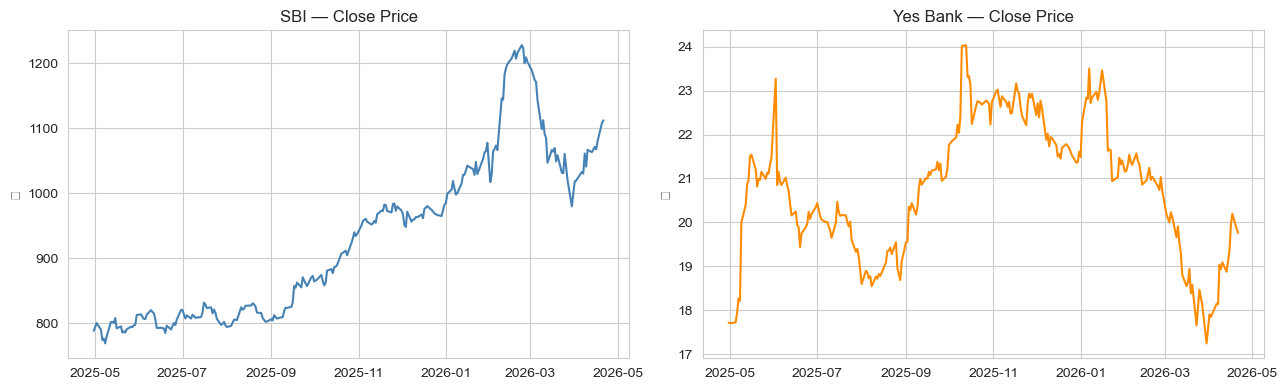

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(sbi.index, sbi['Close Price'], color='steelblue')
axes[0].set_title('SBI — Close Price')
axes[0].set_ylabel('₹')

axes[1].plot(yesbank.index, yesbank['Close Price'], color='darkorange')
axes[1].set_title('Yes Bank — Close Price')
axes[1].set_ylabel('₹')

plt.tight_layout()
plt.show()


### 7.2  Daily return series

Returns *are* comparable across stocks (they're percentages), so we can plot them on the same y-axis if we want. Here we keep two subplots to avoid a messy overlap.


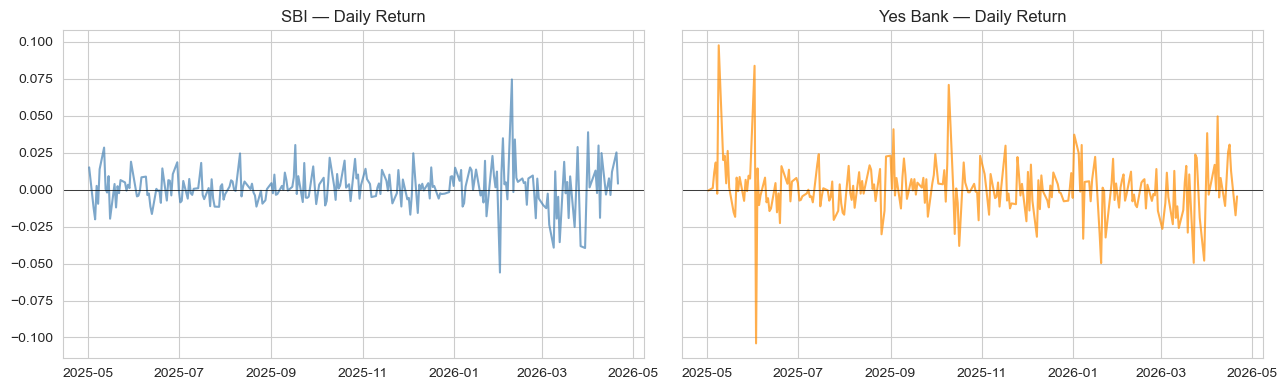

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

axes[0].plot(sbi.index, sbi['DailyReturn'], color='steelblue', alpha=0.7)
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_title('SBI — Daily Return')

axes[1].plot(yesbank.index, yesbank['DailyReturn'], color='darkorange', alpha=0.7)
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_title('Yes Bank — Daily Return')

plt.tight_layout()
plt.show()


Notice **volatility clustering**: turbulent days tend to appear in bunches rather than being evenly spread through time. This is a well-known stylised fact of financial returns.


### 7.3  Histogram + KDE — side by side


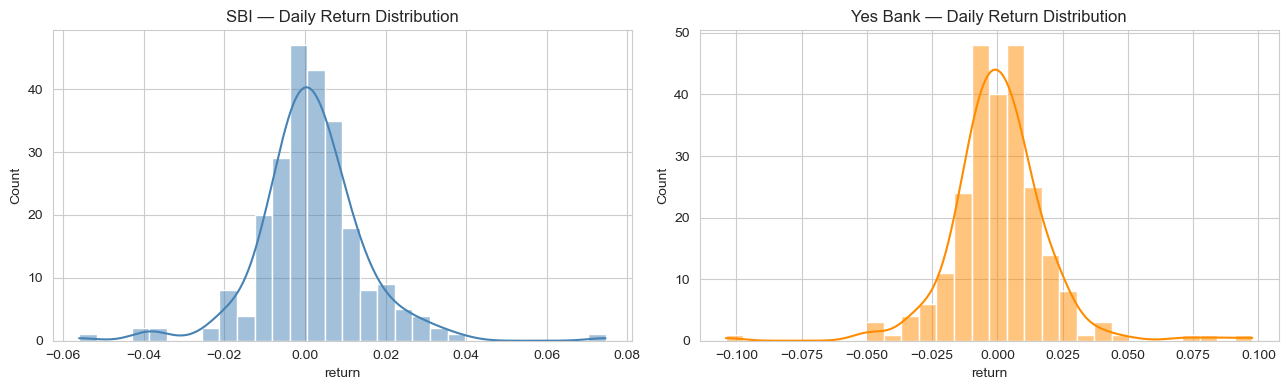

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(sbi['DailyReturn'].dropna(), kde=True, bins=30,
             color='steelblue', ax=axes[0])
axes[0].set_title('SBI — Daily Return Distribution')
axes[0].set_xlabel('return')

sns.histplot(yesbank['DailyReturn'].dropna(), kde=True, bins=30,
             color='darkorange', ax=axes[1])
axes[1].set_title('Yes Bank — Daily Return Distribution')
axes[1].set_xlabel('return')

plt.tight_layout()
plt.show()


### 7.4  KDE overlay — both on one axis

Since returns are comparable in scale (both are in the low-single-digit-percent range), we *can* overlay them to compare shape directly.


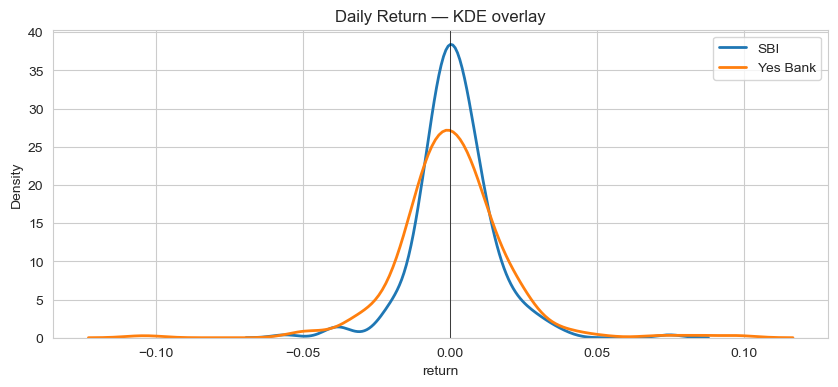

In [34]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.kdeplot(sbi['DailyReturn'].dropna(),     label='SBI',      ax=ax, linewidth=2)
sns.kdeplot(yesbank['DailyReturn'].dropna(), label='Yes Bank', ax=ax, linewidth=2)
ax.axvline(0, color='black', lw=0.5)
ax.set_title('Daily Return — KDE overlay')
ax.set_xlabel('return')
ax.legend()
plt.show()


### 7.5  Boxplots

Boxplots compress a whole distribution into a compact summary:

- box = IQR (25th–75th percentile), line = median
- whiskers extend to the furthest point within 1.5 × IQR
- points beyond the whiskers are **statistical outliers** (we'll explore these in Section 9)


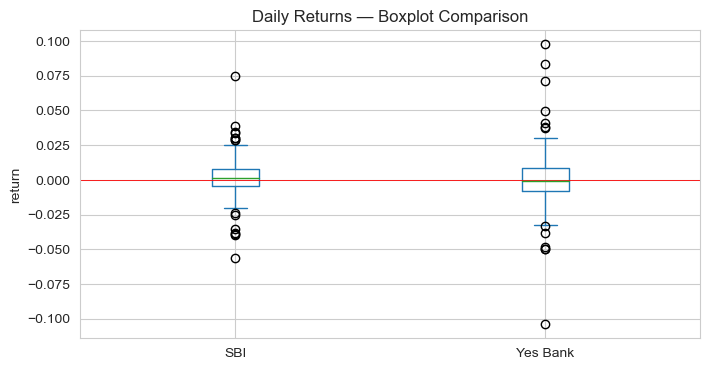

In [35]:
daily_both = pd.DataFrame({
    'SBI':      sbi['DailyReturn'],
    'Yes Bank': yesbank['DailyReturn'],
})

fig, ax = plt.subplots(figsize=(8, 4))
daily_both.plot.box(ax=ax)
ax.axhline(0, color='red', lw=0.6)
ax.set_title('Daily Returns — Boxplot Comparison')
ax.set_ylabel('return')
plt.show()


### 7.6  Q-Q plots vs normal

A Q-Q plot compares the empirical quantiles of our data to the theoretical quantiles of a normal distribution. If the two match, points fall on a straight line. Departures **at the extremes** indicate fat tails.


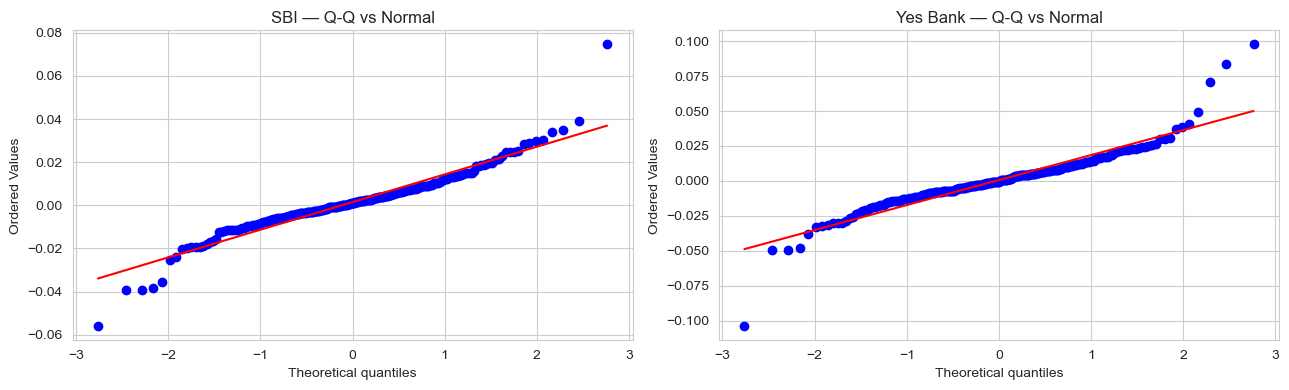

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

stats.probplot(sbi['DailyReturn'].dropna(),     dist='norm', plot=axes[0])
axes[0].set_title('SBI — Q-Q vs Normal')

stats.probplot(yesbank['DailyReturn'].dropna(), dist='norm', plot=axes[1])
axes[1].set_title('Yes Bank — Q-Q vs Normal')

plt.tight_layout()
plt.show()


Look at the tails — points curve away from the diagonal on both ends. That's the visual signature of **fat tails**: returns have more extreme values than a normal distribution would produce.


### 7.7  Rolling Volatility

A common analyst chart: the 21-day rolling standard deviation of daily returns, scaled up to an annual number by multiplying by $\sqrt{252}$ (trading days per year).


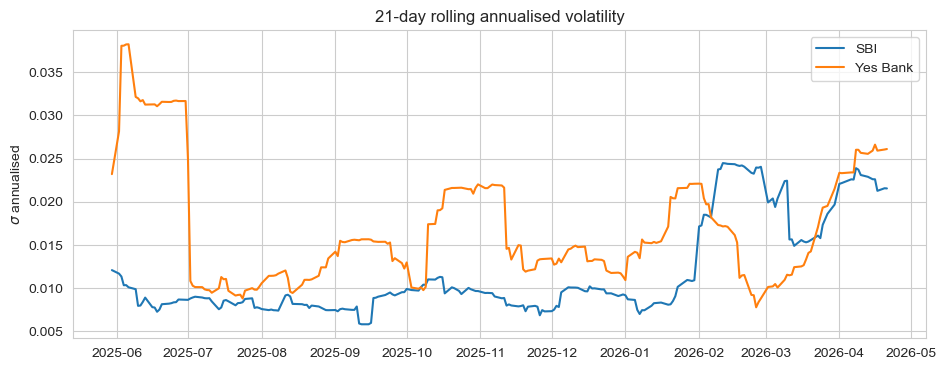

In [52]:
sbi_rolling_vol     = sbi['DailyReturn'].rolling(21).std()     
yesbank_rolling_vol = yesbank['DailyReturn'].rolling(21).std() 
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(sbi_rolling_vol.index,     sbi_rolling_vol,     label='SBI',      linewidth=1.5)
ax.plot(yesbank_rolling_vol.index, yesbank_rolling_vol, label='Yes Bank', linewidth=1.5)
ax.set_title('21-day rolling annualised volatility')
ax.set_ylabel(r'$\sigma$ annualised')
ax.legend()
plt.show()


> **Intermediate exercise 7.1**
>
> Pick the stock that shows the most variable rolling volatility. Identify the **top-3 most volatile 21-day windows** (highest rolling-vol values). What were the end dates of those windows? Can you find news events from around those dates that might explain the turbulence?


## 8. Outlier analysis

Two standard rule-of-thumb outlier detectors:

- **IQR rule**: flag if the value is outside $[Q_1 - 1.5 \cdot \text{IQR},\ Q_3 + 1.5 \cdot \text{IQR}]$.
- **z-score rule**: flag if $|z| > 3$, where $z = (x - \bar{x}) / s$.

They disagree in interesting ways for fat-tailed data, so we'll compute both.


### 8.1  IQR outliers for SBI

Step 1 — compute the quartiles and the IQR.


In [41]:
q1 = sbi['DailyReturn'].quantile(0.25)
q3 = sbi['DailyReturn'].quantile(0.75)
iqr = q3 - q1
print('Q1:', round(q1, 4))
print('Q3:', round(q3, 4))
print('IQR:', round(iqr, 4))


Q1: -0.0047
Q3: 0.0076
IQR: 0.0123


Step 2 — compute the lower and upper bounds.


In [42]:
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
print('Lower bound:', round(lower, 4))
print('Upper bound:', round(upper, 4))


Lower bound: -0.0231
Upper bound: 0.026


Step 3 — select the rows where the return is outside those bounds.


In [43]:
sbi_iqr_outliers = sbi[(sbi['DailyReturn'] < lower) | (sbi['DailyReturn'] > upper)]
print('Number of IQR outliers (SBI):', len(sbi_iqr_outliers))
sbi_iqr_outliers[['Close Price', 'DailyReturn']].head(10)


Number of IQR outliers (SBI): 15


,Close Price,DailyReturn
Date,,
2025-05-12,801.60,0.0285
2025-09-17,856.95,0.0302
2026-02-01,1017.15,-0.0561
2026-02-03,1064.25,0.0348
2026-02-09,1145.95,0.0746
2026-02-11,1183.00,0.0340
2026-03-06,1143.55,-0.0237
2026-03-09,1098.70,-0.0392
2026-03-13,1046.80,-0.0355


### 8.2  IQR outliers for Yes Bank — same three steps


In [44]:
q1 = yesbank['DailyReturn'].quantile(0.25)
q3 = yesbank['DailyReturn'].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

yesbank_iqr_outliers = yesbank[(yesbank['DailyReturn'] < lower) | (yesbank['DailyReturn'] > upper)]
print('Yes Bank — Q1:', round(q1, 4), ' Q3:', round(q3, 4), ' IQR:', round(iqr, 4))
print('Lower bound:', round(lower, 4), ' Upper bound:', round(upper, 4))
print('Number of IQR outliers (Yes Bank):', len(yesbank_iqr_outliers))


Yes Bank — Q1: -0.0079  Q3: 0.0086  IQR: 0.0165
Lower bound: -0.0326  Upper bound: 0.0333
Number of IQR outliers (Yes Bank): 13


### 8.3  z-score outliers for SBI

Step 1 — compute the z-score of each day's return.


In [45]:
sbi_z = (sbi['DailyReturn'] - sbi['DailyReturn'].mean()) / sbi['DailyReturn'].std()
sbi_z.head()


Date
2025-04-30       NaN
2025-05-02    1.0223
2025-05-05   -1.0598
2025-05-06   -1.6245
2025-05-07    0.0802
Name: DailyReturn, dtype: float64

Step 2 — keep only the rows with |z| > 3.


In [46]:
sbi_z_outliers = sbi[sbi_z.abs() > 3].copy()
sbi_z_outliers['z_score'] = sbi_z[sbi_z.abs() > 3]
print('Number of z-score outliers (SBI):', len(sbi_z_outliers))
sbi_z_outliers[['Close Price', 'DailyReturn', 'z_score']].sort_values('z_score')


Number of z-score outliers (SBI): 4


,Close Price,DailyReturn,z_score
Date,,,
2026-02-01,1017.15,-0.0561,-4.3336
2026-03-30,979.80,-0.0395,-3.0845
2026-03-09,1098.70,-0.0392,-3.0665
2026-02-09,1145.95,0.0746,5.5010


### 8.4  z-score outliers for Yes Bank


In [47]:
yesbank_z = (yesbank['DailyReturn'] - yesbank['DailyReturn'].mean()) / yesbank['DailyReturn'].std()
yesbank_z_outliers = yesbank[yesbank_z.abs() > 3].copy()
yesbank_z_outliers['z_score'] = yesbank_z[yesbank_z.abs() > 3]
print('Number of z-score outliers (Yes Bank):', len(yesbank_z_outliers))
yesbank_z_outliers[['Close Price', 'DailyReturn', 'z_score']].sort_values('z_score')


Number of z-score outliers (Yes Bank): 4


,Close Price,DailyReturn,z_score
Date,,,
2025-06-03,20.85,-0.1040,-5.5268
2025-10-10,24.01,0.0709,3.7130
2025-06-02,23.27,0.0838,4.3954
2025-05-09,20.00,0.0977,5.1274


### 9.5  Why do the two rules disagree?

The z-score rule uses the sample **mean** and **standard deviation**. Both are heavily influenced by the very outliers we're trying to detect — one extreme day inflates `s` and can *mask* other outliers. The IQR rule uses **quartiles**, which are robust to a handful of extreme observations, so it tends to flag **more** outliers on fat-tailed data.

> **Intermediate exercise 9.1**
>
> For SBI, find the set of days flagged by **IQR only**, **z-score only**, and **both**. Which rule flagged more? Does that match the fat-tail argument above?


## 9. Standardisation — comparing apples to apples

Even after switching from prices to returns, the two stocks have different typical return magnitudes (different volatilities). **Standardisation** removes that by dividing out each stock's own mean and standard deviation:

$$
z_t = \frac{r_t - \bar{r}}{s}
$$

After this transformation each series has **mean ≈ 0** and **std ≈ 1**. Any remaining differences between the two stocks are differences of **shape** — skew, kurtosis, tail behaviour.


### 9.1  Standardise SBI's daily returns


In [48]:
sbi_std = (sbi['DailyReturn'] - sbi['DailyReturn'].mean()) / sbi['DailyReturn'].std()
print('mean:', round(sbi_std.mean(), 6))
print('std :', round(sbi_std.std(),  6))
sbi_std.head()


mean: 0.0
std : 1.0


Date
2025-04-30       NaN
2025-05-02    1.0223
2025-05-05   -1.0598
2025-05-06   -1.6245
2025-05-07    0.0802
Name: DailyReturn, dtype: float64

### 9.2  Standardise Yes Bank's daily returns


In [49]:
yesbank_std = (yesbank['DailyReturn'] - yesbank['DailyReturn'].mean()) / yesbank['DailyReturn'].std()
print('mean:', round(yesbank_std.mean(), 6))
print('std :', round(yesbank_std.std(),  6))
yesbank_std.head()


mean: -0.0
std : 1.0


Date
2025-04-30       NaN
2025-05-02   -0.0631
2025-05-05    0.0264
2025-05-06    0.5924
2025-05-07    0.9384
Name: DailyReturn, dtype: float64

### 9.3  Overlay both standardised distributions with a N(0, 1) reference


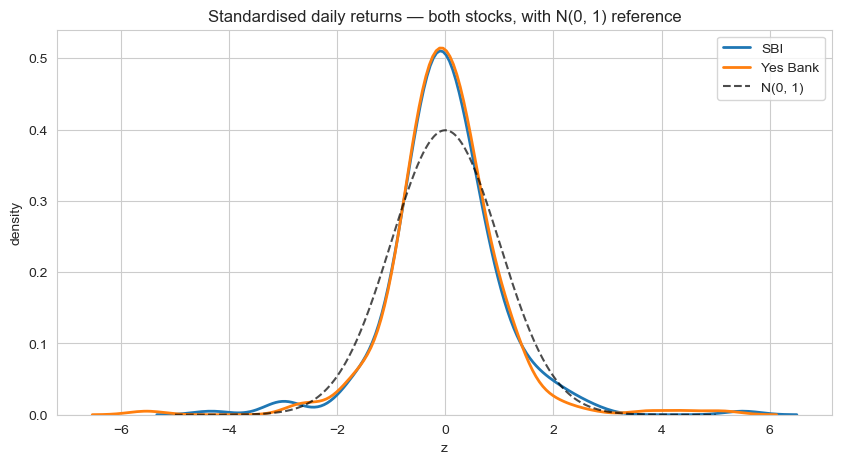

In [50]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(sbi_std.dropna(),     label='SBI',      ax=ax, linewidth=2)
sns.kdeplot(yesbank_std.dropna(), label='Yes Bank', ax=ax, linewidth=2)

# Standard normal reference curve
x = np.linspace(-5, 5, 400)
ax.plot(x, stats.norm.pdf(x), 'k--', label='N(0, 1)', alpha=0.7)

ax.set_title('Standardised daily returns — both stocks, with N(0, 1) reference')
ax.set_xlabel('z')
ax.set_ylabel('density')
ax.legend()
plt.show()


Now the two stocks share a common axis. Any remaining differences — a more peaked centre, fatter tails, a long left shoulder — reflect **real shape differences**, not just scale differences.

> **Intermediate exercise 10.1**
>
> Standardise the **weekly** returns in the same way (for both stocks) and overlay them together with the N(0, 1) curve. Do the two stocks look closer to each other — and to the normal — at the weekly horizon?


---

## End-of-notebook exercises

### Exercise 1 — Bring in a third stock

Load it following exactly the same steps you used for SBI and Yes Bank (§1 and §2). Then reproduce:

- the daily and weekly `describe()` outputs,
- the daily return histogram + KDE,
- the IQR and z-score outlier counts,
- the standardised-return KDE (add the stock as a third line to the plot in §10.3).

Write a short comment (2–3 sentences) on how stock compares to the other two — which is the most volatile? Which has the fattest tails?

